# Pulsation snapshots gallery

Companion to `spots_configurations.ipynb` and `spot_smoothness.ipynb`. Each row is one pulsation configuration — a stack of overlapping vector spherical-harmonic modes added with `add_pulsations` — evaluated with `evaluate_pulsations` at five evenly spaced phases over one common period. The mesh in each panel is the *deformed* surface (`d_vertices + vertices_pulsation_offsets`) coloured by the per-face *radial* offset $\xi_r = \hat r \cdot \Delta\vec r$ at that time. A single shared diverging colorbar at the bottom maps the same range across every panel so the time evolution and inter-row contrast are directly comparable.

The exact mode list for every row is exported to `pulsation_snapshots_modes.tex` for the paper.

In [10]:
import sys
sys.path.append('../../../src')

from spice.models import IcosphereModel
from spice.models.mesh_transform import add_pulsations, evaluate_pulsations

import jax.numpy as jnp
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import art3d

%matplotlib inline

## Base mesh

Pulsation requires the mesh to be sized for `max_pulsation_mode` (max `ℓ + 1` we will use) and `max_fourier_order` (max number of Fourier terms per VSH amplitude). One Fourier term per mode is enough for a single-frequency sinusoidal oscillation.

In [11]:
T_BASE = 5800.0

base_mesh = IcosphereModel.construct(
    n_vertices=5000,
    radius=1.0,
    mass=1.0,
    parameters=jnp.array([T_BASE]),
    parameter_names=['teff'],
    override_log_g=False,
    max_pulsation_mode=8,
    max_fourier_order=2,
)

[spice] IcosphereModel constructed in 0.1 s


## Pulsation configurations

Three multi-mode stacks, each combining 2 – 3 overlapping vector spherical harmonics with their own period and amplitude. Each entry's mode list is fed to `add_pulsations` to register all VSH components on the mesh; `evaluate_pulsations(mesh, t)` then computes the time-dependent vertex / face-centre offsets at any phase `t`.

In [12]:
Z_AXIS = jnp.array([0.0, 0.0, 1.0])
Y_AXIS = jnp.array([0.0, 1.0, 0.0])
X_AXIS = jnp.array([1.0, 0.0, 0.0])

AMPLITUDE = 0.10  # radial Fourier amplitude (fraction of R_base)

def mode(l, m, period, amp=AMPLITUDE, tilt_axis=Z_AXIS, tilt_angle=0.0):
    return {'l': l, 'm': m, 'period': period, 'amp': amp,
            'tilt_axis': tilt_axis, 'tilt_angle': tilt_angle}

configurations = [
    {'title': r'a)',
     'modes': [mode(l=2, m=2, period=1.0),
               mode(l=4, m=2, period=0.7)]},
    {'title': r'b)',
     'modes': [mode(l=2, m=1, period=1.0),
               mode(l=2, m=1, period=0.7,
                    tilt_axis=Y_AXIS, tilt_angle=60.0)]},
    {'title': r'c)',
     'modes': [mode(l=3, m=2, period=1.0),
               mode(l=3, m=2, period=0.8,
                    tilt_axis=Y_AXIS, tilt_angle=60.0),
               mode(l=3, m=2, period=0.6,
                    tilt_axis=X_AXIS, tilt_angle=60.0)]},
]

def make_pulsated_mesh(base, modes_list):
    n = len(modes_list)
    m_orders   = jnp.asarray([mo['m'] for mo in modes_list], dtype=jnp.int32)
    l_degrees  = jnp.asarray([mo['l'] for mo in modes_list], dtype=jnp.int32)
    periods    = jnp.asarray([mo['period'] for mo in modes_list], dtype=jnp.float32)
    # Pure radial pulsation: only the [radial, term 0, amplitude] slot is nonzero.
    fourier = np.zeros((n, 3, 1, 2), dtype=np.float32)
    for i, mo in enumerate(modes_list):
        fourier[i, 0, 0, 0] = mo['amp']
    tilt_axes  = jnp.stack([jnp.asarray(mo['tilt_axis']) for mo in modes_list])
    tilt_angles = jnp.asarray([mo['tilt_angle'] for mo in modes_list], dtype=jnp.float32)
    return add_pulsations(base, m_orders, l_degrees, periods,
                          jnp.asarray(fourier), tilt_axes, tilt_angles)

pulsated_meshes = [make_pulsated_mesh(base_mesh, c['modes']) for c in configurations]

## Evaluate at five phases

We evaluate every configuration at five times spread across one common reference period `T_REF = 1.0 d`, then extract the deformed mesh elements (`d_vertices + vertices_pulsation_offsets`) and the per-face radial offset (`r̂ · Δr`) for colouring.

In [13]:
T_REF = 1.0  # days, reference period for the snapshot grid
PHASES = np.linspace(0.0, 1.0, 5, endpoint=True)
TIMES = PHASES * T_REF

def deformed_elements_and_radial(mesh_t):
    """Return (n_faces, 3, 3) deformed triangle vertices + per-face radial offset."""
    base_v   = np.asarray(mesh_t.d_vertices)
    offset_v = np.asarray(mesh_t.vertices_pulsation_offsets)
    deformed = base_v + offset_v
    faces = np.asarray(mesh_t.faces).astype(int)
    elements = deformed[faces]                          # (n_faces, 3, 3)

    centers   = np.asarray(mesh_t.d_centers)
    c_offsets = np.asarray(mesh_t.center_pulsation_offsets)
    r_hat = centers / (np.linalg.norm(centers, axis=1, keepdims=True) + 1e-12)
    radial = np.sum(c_offsets * r_hat, axis=1)         # signed radial offset
    return elements, radial

snapshots = []  # snapshots[row][col] = (elements, radial)
for mesh in pulsated_meshes:
    row = []
    for t in TIMES:
        evaluated = evaluate_pulsations(mesh, t=float(t))
        row.append(deformed_elements_and_radial(evaluated))
    snapshots.append(row)

all_radial = np.concatenate([r for row in snapshots for (_, r) in row])
VMAX = float(np.max(np.abs(all_radial)))
print(f'Symmetric colour range: +/- {VMAX:.4f} R_base across {len(snapshots)}x{len(PHASES)} panels')

[spice] Pulsations evaluated in 0.0 s


[spice] Pulsations evaluated in 0.1 s
[spice] Pulsations evaluated in 0.0 s
[spice] Pulsations evaluated in 0.0 s
[spice] Pulsations evaluated in 0.0 s
[spice] Pulsations evaluated in 0.0 s
[spice] Pulsations evaluated in 0.0 s
[spice] Pulsations evaluated in 0.0 s
[spice] Pulsations evaluated in 0.0 s
[spice] Pulsations evaluated in 0.0 s
[spice] Pulsations evaluated in 0.0 s
[spice] Pulsations evaluated in 0.0 s
[spice] Pulsations evaluated in 0.0 s
[spice] Pulsations evaluated in 0.0 s
[spice] Pulsations evaluated in 0.0 s
Symmetric colour range: +/- 0.1569 R_base across 3x5 panels


## Render the snapshot grid

Rows are configurations, columns are time phases, the colorbar at the bottom is shared across every panel. Camera, edge colour, rasterisation and colorbar layout match the spots paper figures so the three plates can sit on the same page.

In [14]:
import cmasher as cm

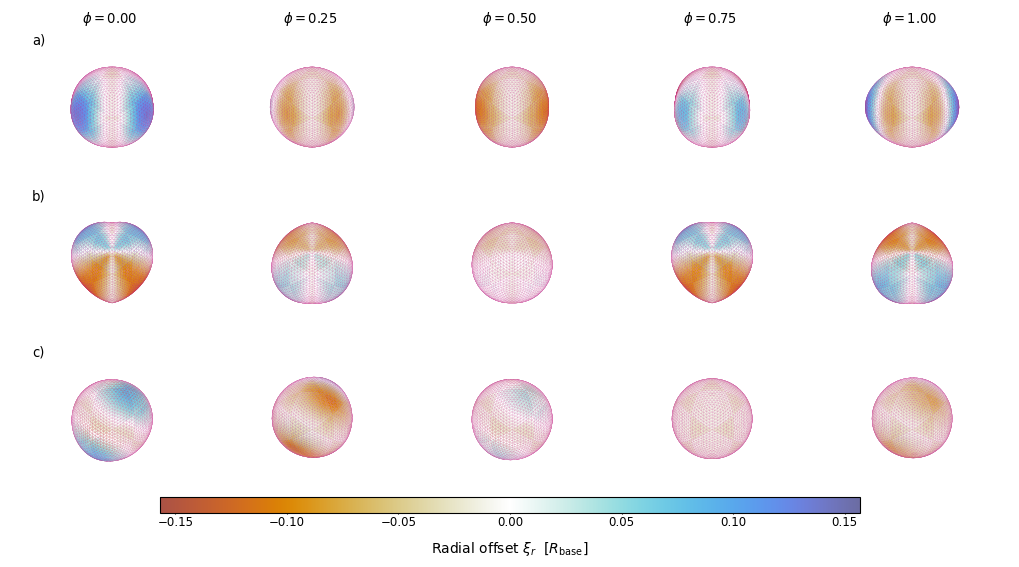

In [15]:
ROW_SPACING = 0.0
HEIGHT_PER_ROW = 1.5
CBAR_HEIGHT_RATIO = 0.08

CMAP = 'cmr.prinsenvlag'
VIEW = dict(elev=15, azim=0)

norm = mpl.colors.Normalize(vmin=-VMAX, vmax=+VMAX)
cmap = mpl.colormaps[CMAP]

def strip_axes(ax):
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.fill = False
        axis.pane.set_edgecolor('none')
    ax.grid(False)
    ax.set_axis_off()
    ax.set_facecolor('none')

def draw_panel(ax, elements, radial, lim):
    poly = art3d.Poly3DCollection(
        elements,
        facecolors=cmap(norm(radial)),
        edgecolor='mediumvioletred', linewidths=0.05)
    poly.set_rasterized(True)
    ax.add_collection(poly)
    ax.set(xlim=(-lim, lim), ylim=(-lim, lim), zlim=(-lim, lim))
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(**VIEW)

n_rows = len(configurations)
n_cols = len(PHASES)
# Pulsation can push vertices outward by ~AMPLITUDE so widen the box a touch.
PANEL_LIM = 1.05 * float(base_mesh.radius) * (1.0 + AMPLITUDE)

fig = plt.figure(figsize=(2 * n_cols, HEIGHT_PER_ROW * n_rows + 0.3))
gs = fig.add_gridspec(
    n_rows + 1, n_cols,
    height_ratios=[1] * n_rows + [CBAR_HEIGHT_RATIO],
    wspace=0, hspace=ROW_SPACING)

for r, (cfg, row_snapshots) in enumerate(zip(configurations, snapshots)):
    for c, (elements, radial) in enumerate(row_snapshots):
        ax = fig.add_subplot(gs[r, c], projection='3d')
        strip_axes(ax)
        draw_panel(ax, elements, radial, PANEL_LIM)
        if r == 0:
            ax.set_title(rf'$\phi = {PHASES[c]:.2f}$', fontsize=9.5, pad=0.01, y=1.15)
        if c == 0:
            # Place row label in the leftmost column, just above the panel.
            ax.text2D(0.0, 0.9, cfg['title'], transform=ax.transAxes,
                      fontsize=9.5, ha='left', va='bottom')

cax = fig.add_subplot(gs[-1, :])
cax.axis('off')
inset_ax = cax.inset_axes([0.5 - 0.7 / 2, -0.125, 0.7, 1.25])

cbar = fig.colorbar(
    mpl.cm.ScalarMappable(cmap=cmap, norm=norm),
    cax=inset_ax,
    orientation='horizontal',
)
cbar.set_label(r'Radial offset $\xi_r$  [$R_{\mathrm{base}}$]', fontsize=10, labelpad=8)
cbar.ax.tick_params(length=1, labelsize=8.5, pad=0.5)
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
fig.savefig('pulsation_snapshots.pdf', bbox_inches='tight', dpi=300)
plt.show()

## LaTeX mode-listing table

The exact `(ℓ, m, period, amplitude, tilt axis, tilt angle)` for every mode in every row, generated from the same `configurations` list that drives the figure so the two never drift. Requires `\usepackage{booktabs, multirow}`. The cell prints the LaTeX and writes it to `pulsation_snapshots_modes.tex` for `\input{}` from a paper.

In [16]:
def axis_label(axis):
    a = np.asarray(axis).astype(float)
    a = a / (np.linalg.norm(a) + 1e-12)
    for name, ref in [(r'\hat z', [0, 0, 1]),
                      (r'\hat y', [0, 1, 0]),
                      (r'\hat x', [1, 0, 0])]:
        if np.allclose(a, ref, atol=1e-6):
            return name
    return rf'({a[0]:+.2f},\,{a[1]:+.2f},\,{a[2]:+.2f})'

def panel_label(title):
    head = title.split(')', 1)[0].strip()
    return head if len(head) == 1 else title

lines = [
    r'\begin{table}',
    r'\centering',
    r'\caption{Pulsation modes summed in each row of the snapshot gallery. Every row stacks 2--3 overlapping vector spherical-harmonic modes; columns are five evenly spaced phases over $T_{\mathrm{ref}} = 1\,\mathrm{d}$. Tilt angle $\theta = 0$ means the pulsation axis coincides with the rotation axis $\hat z$.}',
    r'\label{tab:pulsation_snapshot_modes}',
    r'\begin{tabular}{@{}llrrrrlr@{}}',
    r'\toprule',
    r'Row & \# & $\ell$ & $m$ & $P$ [d] & $a_r$ [$R_{\mathrm{base}}$] & Tilt axis & $\theta$ [$^\circ$] \\',
    r'\midrule',
]
for cfg_idx, cfg in enumerate(configurations):
    label = panel_label(cfg['title'])
    n = len(cfg['modes'])
    for k, mo in enumerate(cfg['modes'], 1):
        if k == 1:
            row_cell = rf'\multirow{{{n}}}{{*}}{{{label}}}'
        else:
            row_cell = ''
        tilt_str  = '$' + axis_label(mo['tilt_axis']) + '$'
        angle_str = f"{float(mo['tilt_angle']):.0f}"
        lines.append(
            f"{row_cell} & {k} & {int(mo['l'])} & {int(mo['m'])} & "
            f"{float(mo['period']):.2f} & {float(mo['amp']):.3f} & "
            f"{tilt_str} & {angle_str} \\\\"
        )
    if cfg_idx != len(configurations) - 1:
        lines.append(r'\midrule')
lines += [r'\bottomrule', r'\end{tabular}', r'\end{table}']

latex = '\n'.join(lines)
print(latex)

with open('pulsation_snapshots_modes.tex', 'w') as f:
    f.write(latex + '\n')

\begin{table}
\centering
\caption{Pulsation modes summed in each row of the snapshot gallery. Every row stacks 2--3 overlapping vector spherical-harmonic modes; columns are five evenly spaced phases over $T_{\mathrm{ref}} = 1\,\mathrm{d}$. Tilt angle $\theta = 0$ means the pulsation axis coincides with the rotation axis $\hat z$.}
\label{tab:pulsation_snapshot_modes}
\begin{tabular}{@{}llrrrrlr@{}}
\toprule
Row & \# & $\ell$ & $m$ & $P$ [d] & $a_r$ [$R_{\mathrm{base}}$] & Tilt axis & $\theta$ [$^\circ$] \\
\midrule
\multirow{2}{*}{a} & 1 & 2 & 2 & 1.00 & 0.100 & $\hat z$ & 0 \\
 & 2 & 4 & 2 & 0.70 & 0.100 & $\hat z$ & 0 \\
\midrule
\multirow{2}{*}{b} & 1 & 2 & 1 & 1.00 & 0.100 & $\hat z$ & 0 \\
 & 2 & 2 & 1 & 0.70 & 0.100 & $\hat y$ & 60 \\
\midrule
\multirow{3}{*}{c} & 1 & 3 & 2 & 1.00 & 0.100 & $\hat z$ & 0 \\
 & 2 & 3 & 2 & 0.80 & 0.100 & $\hat y$ & 60 \\
 & 3 & 3 & 2 & 0.60 & 0.100 & $\hat x$ & 60 \\
\bottomrule
\end{tabular}
\end{table}
